In [2]:
import numpy as np

def step(z):
    return 1 if z >= 0 else 0

def perceptron(x1, x2):
    z = 2 * x1 - x2 + 1
    y = step(z)
    return z, y

points = [(1, 0), (0, 2)]

for p in points:
    z, y = perceptron(*p)
    print(f"(x1, x2) = {p} -> z = {z}, y = {y}")

print("Шешім шекарасы: 2*x1 - x2 + 1 = 0")
print("Яғни: x2 = 2*x1 + 1")

(x1, x2) = (1, 0) -> z = 3, y = 1
(x1, x2) = (0, 2) -> z = -1, y = 0
Шешім шекарасы: 2*x1 - x2 + 1 = 0
Яғни: x2 = 2*x1 + 1


1) Бір қабатты перцептрон XOR-ды үйрене алмайды, себебі XOR сызықтық бөлінбейді.
2) Геометриялық тұрғыда 0 және 1 кластары бір түзу арқылы ажыратылмайды.
3) XOR-ды шешетін архитектура: көпқабатты перцептрон (MLP), мысалы 2-2-1.


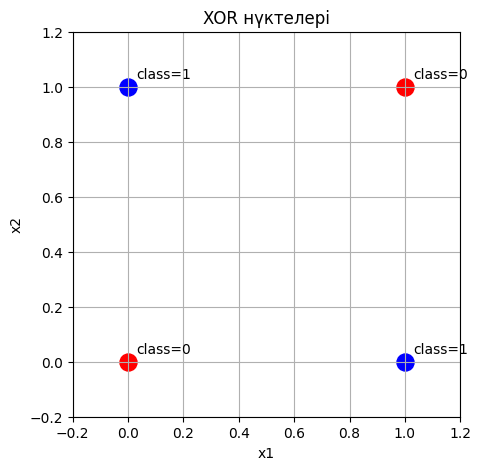

In [3]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 0])  # XOR

print("1) Бір қабатты перцептрон XOR-ды үйрене алмайды, себебі XOR сызықтық бөлінбейді.")
print("2) Геометриялық тұрғыда 0 және 1 кластары бір түзу арқылы ажыратылмайды.")
print("3) XOR-ды шешетін архитектура: көпқабатты перцептрон (MLP), мысалы 2-2-1.")

plt.figure(figsize=(5, 5))
for i, (x1, x2) in enumerate(X):
    color = "red" if y[i] == 0 else "blue"
    plt.scatter(x1, x2, s=150, c=color)
    plt.text(x1 + 0.03, x2 + 0.03, f"class={y[i]}", fontsize=10)

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR нүктелері")
plt.grid(True)
plt.show()

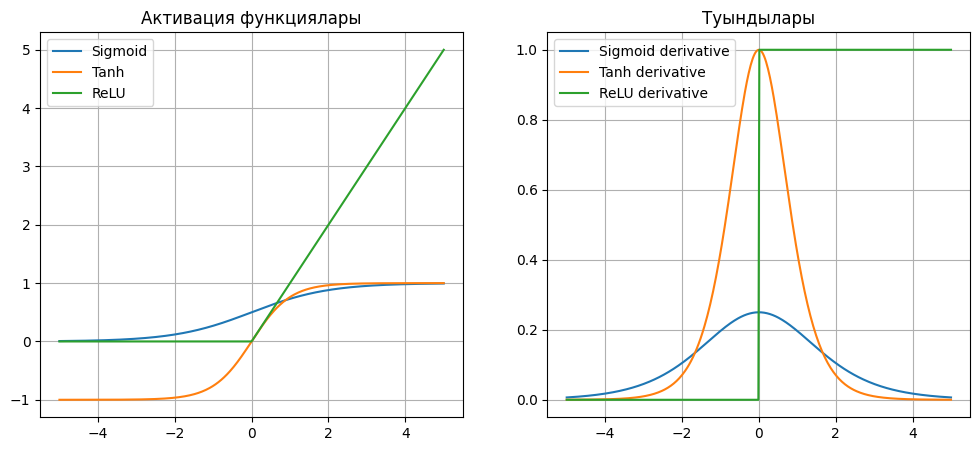

Sigmoid шығу диапазоны: (0, 1)
Tanh шығу диапазоны: (-1, 1)
ReLU шығу диапазоны: [0, +inf)
Vanishing gradient-ке ең бейім: Sigmoid
Одан кейін: Tanh
Ең төзімді: ReLU


In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 400)

sigmoid = 1 / (1 + np.exp(-x))
dsigmoid = sigmoid * (1 - sigmoid)

tanh = np.tanh(x)
dtanh = 1 - tanh**2

relu = np.maximum(0, x)
drelu = (x > 0).astype(float)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, tanh, label="Tanh")
plt.plot(x, relu, label="ReLU")
plt.title("Активация функциялары")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, dsigmoid, label="Sigmoid derivative")
plt.plot(x, dtanh, label="Tanh derivative")
plt.plot(x, drelu, label="ReLU derivative")
plt.title("Туындылары")
plt.grid(True)
plt.legend()

plt.show()

print("Sigmoid шығу диапазоны: (0, 1)")
print("Tanh шығу диапазоны: (-1, 1)")
print("ReLU шығу диапазоны: [0, +inf)")
print("Vanishing gradient-ке ең бейім: Sigmoid")
print("Одан кейін: Tanh")
print("Ең төзімді: ReLU")

In [5]:
import numpy as np

z = np.array([2.0, 1.0, 0.0])

exp_z = np.exp(z - np.max(z))
softmax = exp_z / np.sum(exp_z)

print("Логиттер:", z)
print("Softmax:", softmax)
print("Ең ықтимал класс индексі:", np.argmax(softmax))
print("Softmax қосындысы:", np.sum(softmax))

Логиттер: [2. 1. 0.]
Softmax: [0.66524096 0.24472847 0.09003057]
Ең ықтимал класс индексі: 0
Softmax қосындысы: 0.9999999999999999


In [6]:
import numpy as np

x = np.array([1, 2])
W = np.array([
    [1, -1],
    [2,  0]
])
b = np.array([0, 1])

z = W @ x + b
a = np.maximum(0, z)  # ReLU

print("z =", z)
print("a = ReLU(z) =", a)

z = [-1  3]
a = ReLU(z) = [0 3]


In [7]:
import numpy as np

y = 1
y_hat = 0.8

L = -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

print("Жоғалту L =", L)

Жоғалту L = 0.2231435513142097


In [8]:
y = 0
y_hat = 0.3

delta = y_hat - y

print("delta =", delta)

if delta > 0:
    print("Белгісі оң: модель 0 орнына 1 жағына қарай қате болжап тұр.")
elif delta < 0:
    print("Белгісі теріс: модель 1 орнына 0 жағына қарай қате болжап тұр.")
else:
    print("Қате жоқ.")

delta = 0.3
Белгісі оң: модель 0 орнына 1 жағына қарай қате болжап тұр.


In [9]:
import numpy as np

delta_next = np.array([0.2, -0.1])
W_next = np.array([
    [ 1, 2],
    [-1, 1]
])
fprime = np.array([1, 0])

delta_hidden = (W_next.T @ delta_next) * fprime

print("delta^(l) =", delta_hidden)

delta^(l) = [0.3 0. ]


In [10]:
w = 0.5
dL_dw = 0.2
eta = 0.1

w_new = w - eta * dL_dw

print("Жаңартылған салмақ =", w_new)

Жаңартылған салмақ = 0.48


In [11]:
import numpy as np

# AND үшін
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 0, 0, 1], dtype=int)

# OR керек болса, мына жолды қолданыңыз:
# y = np.array([0, 1, 1, 1], dtype=int)

w = np.zeros(2)
b = 0.0
lr = 0.1
epochs = 20

def step(z):
    return 1 if z >= 0 else 0

for epoch in range(epochs):
    for xi, target in zip(X, y):
        z = np.dot(xi, w) + b
        pred = step(z)
        error = target - pred

        w += lr * error * xi
        b += lr * error

preds = np.array([step(np.dot(xi, w) + b) for xi in X])

print("Үйренген салмақтар:", w)
print("Bias:", b)
print("Болжамдар:", preds)
print("Нақты мәндер:", y)
print("Accuracy:", np.mean(preds == y))
print("Қорытынды: бір нейрон AND/OR логикалық функциясын үйрене алады.")

Үйренген салмақтар: [0.2 0.1]
Bias: -0.20000000000000004
Болжамдар: [0 0 0 1]
Нақты мәндер: [0 0 0 1]
Accuracy: 1.0
Қорытынды: бір нейрон AND/OR логикалық функциясын үйрене алады.


MLP болжамдары: [0 0 1 0]
MLP accuracy: 0.75
Перцептрон болжамдары: [1 1 0 0]
Перцептрон accuracy: 0.5


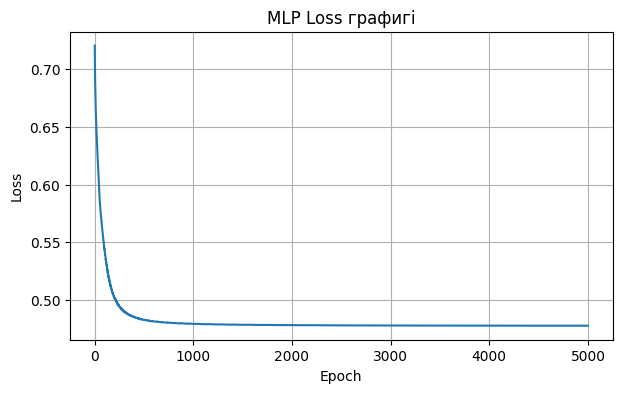

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# XOR деректері
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([[0], [1], [1], [0]], dtype=float)

# -----------------------------
# 1) Бір қабатты перцептронмен салыстыру
# -----------------------------
def train_perceptron(X, y, lr=0.1, epochs=20):
    w = np.zeros((2, 1))
    b = 0.0

    for _ in range(epochs):
        for xi, yi in zip(X, y.ravel()):
            z = xi @ w + b
            pred = 1 if z >= 0 else 0
            err = yi - pred
            w += lr * err * xi.reshape(-1, 1)
            b += lr * err

    preds = (X @ w + b >= 0).astype(int)
    acc = np.mean(preds == y)
    return w, b, preds, acc

# -----------------------------
# 2) 2-hidden-1 MLP: ReLU + Sigmoid
# -----------------------------
def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

np.random.seed(1)

W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))
W2 = np.random.randn(2, 1)
b2 = np.zeros((1, 1))

lr = 0.1
epochs = 5000
losses = []

for epoch in range(epochs):
    # forward
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    y_hat = sigmoid(z2)

    # BCE loss
    loss = -np.mean(y * np.log(y_hat + 1e-8) + (1 - y) * np.log(1 - y_hat + 1e-8))
    losses.append(loss)

    # backward
    dz2 = (y_hat - y) / len(X)
    dW2 = a1.T @ dz2
    db2 = np.sum(dz2, axis=0, keepdims=True)

    da1 = dz2 @ W2.T
    dz1 = da1 * relu_deriv(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # update
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

mlp_preds = (y_hat >= 0.5).astype(int)
mlp_acc = np.mean(mlp_preds == y)

w_p, b_p, perc_preds, perc_acc = train_perceptron(X, y)

print("MLP болжамдары:", mlp_preds.ravel())
print("MLP accuracy:", mlp_acc)
print("Перцептрон болжамдары:", perc_preds.ravel())
print("Перцептрон accuracy:", perc_acc)

plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.title("MLP Loss графигі")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

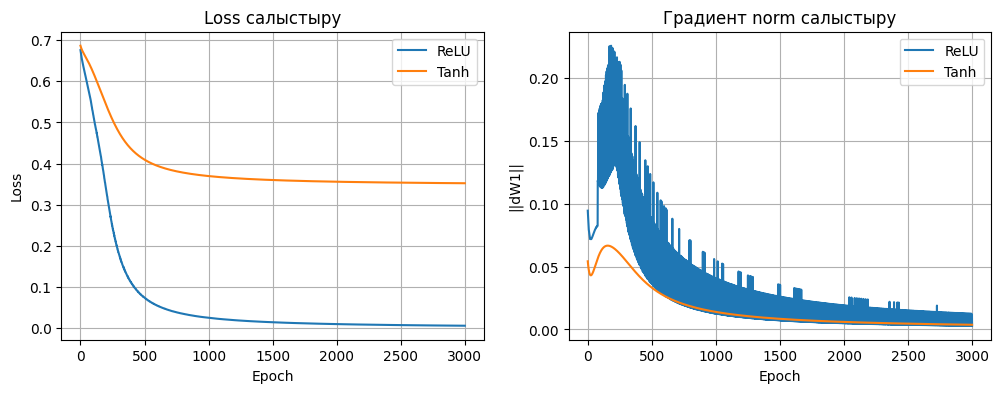

ReLU соңғы loss: 0.006131751311520262
Tanh соңғы loss: 0.35234264914658237
ReLU орташа gradient norm: 0.0051585543397473475
Tanh орташа gradient norm: 0.003841198343815784


In [13]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([[0], [1], [1], [0]], dtype=float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_model(activation="relu", lr=0.1, epochs=3000, seed=1):
    rng = np.random.default_rng(seed)

    W1 = rng.normal(size=(2, 2))
    b1 = np.zeros((1, 2))
    W2 = rng.normal(size=(2, 1))
    b2 = np.zeros((1, 1))

    losses = []
    grad_norms = []

    def act(z):
        if activation == "relu":
            return np.maximum(0, z)
        elif activation == "tanh":
            return np.tanh(z)

    def dact(z):
        if activation == "relu":
            return (z > 0).astype(float)
        elif activation == "tanh":
            return 1 - np.tanh(z) ** 2

    for _ in range(epochs):
        z1 = X @ W1 + b1
        a1 = act(z1)
        z2 = a1 @ W2 + b2
        y_hat = sigmoid(z2)

        loss = -np.mean(y * np.log(y_hat + 1e-8) + (1 - y) * np.log(1 - y_hat + 1e-8))
        losses.append(loss)

        dz2 = (y_hat - y) / len(X)
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ W2.T
        dz1 = da1 * dact(z1)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        grad_norms.append(np.linalg.norm(dW1))

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    return losses, grad_norms

relu_losses, relu_grads = train_model("relu")
tanh_losses, tanh_grads = train_model("tanh")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(relu_losses, label="ReLU")
plt.plot(tanh_losses, label="Tanh")
plt.title("Loss салыстыру")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(relu_grads, label="ReLU")
plt.plot(tanh_grads, label="Tanh")
plt.title("Градиент norm салыстыру")
plt.xlabel("Epoch")
plt.ylabel("||dW1||")
plt.grid(True)
plt.legend()

plt.show()

print("ReLU соңғы loss:", relu_losses[-1])
print("Tanh соңғы loss:", tanh_losses[-1])
print("ReLU орташа gradient norm:", np.mean(relu_grads[-100:]))
print("Tanh орташа gradient norm:", np.mean(tanh_grads[-100:]))

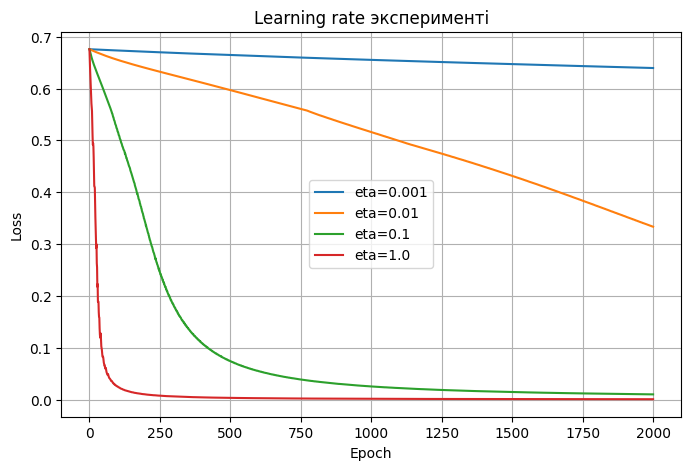

Соңғы loss мәндері:
eta=0.001: 0.6395203145781081
eta=0.01: 0.33342038015465597
eta=0.1: 0.010077160587045463
eta=1.0: 0.0007318781140408181
Оптималды eta: 1.0
Себебі: осы жүгірісте final loss ең кіші мән берді.


In [14]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([[0], [1], [1], [0]], dtype=float)

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train_with_lr(lr, epochs=2000, seed=1):
    rng = np.random.default_rng(seed)

    W1 = rng.normal(size=(2, 2))
    b1 = np.zeros((1, 2))
    W2 = rng.normal(size=(2, 1))
    b2 = np.zeros((1, 1))

    losses = []

    for _ in range(epochs):
        z1 = X @ W1 + b1
        a1 = relu(z1)
        z2 = a1 @ W2 + b2
        y_hat = sigmoid(z2)

        loss = -np.mean(y * np.log(y_hat + 1e-8) + (1 - y) * np.log(1 - y_hat + 1e-8))
        losses.append(loss)

        dz2 = (y_hat - y) / len(X)
        dW2 = a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ W2.T
        dz1 = da1 * relu_deriv(z1)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    return losses

learning_rates = [0.001, 0.01, 0.1, 1.0]
results = {}

plt.figure(figsize=(8, 5))

for lr in learning_rates:
    losses = train_with_lr(lr)
    results[lr] = losses[-1]
    plt.plot(losses, label=f"eta={lr}")

plt.title("Learning rate эксперименті")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

print("Соңғы loss мәндері:")
for lr, loss in results.items():
    print(f"eta={lr}: {loss}")

best_lr = min(results, key=results.get)
print("Оптималды eta:", best_lr)
print("Себебі: осы жүгірісте final loss ең кіші мән берді.")

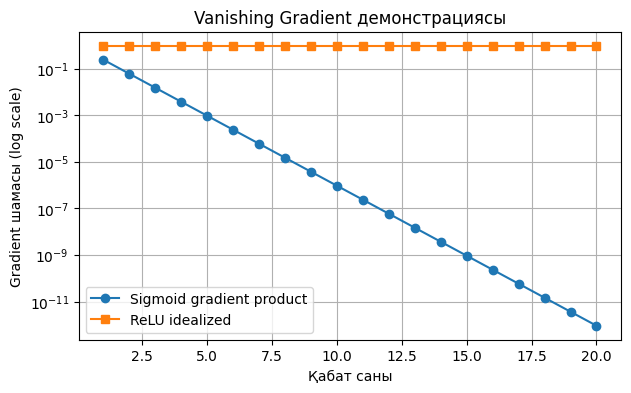

1) Vanishing gradient көп қабатта туындылардың көбейтіндісі өте кішірейгенде пайда болады.
2) Көмектесетін активациялар: ReLU, LeakyReLU, ELU, GELU.
3) BatchNorm рөлі: активацияларды тұрақтандырады, оқытуды жеделдетеді, gradient жоғалуын азайтады.


In [15]:
import numpy as np
import matplotlib.pyplot as plt

layers = np.arange(1, 21)

# Sigmoid үшін туынды максимум 0.25
sigmoid_chain = 0.25 ** layers

# ReLU үшін идеал жағдайда туынды 1 деп аламыз
relu_chain = np.ones_like(layers, dtype=float)

plt.figure(figsize=(7, 4))
plt.semilogy(layers, sigmoid_chain, marker="o", label="Sigmoid gradient product")
plt.semilogy(layers, relu_chain, marker="s", label="ReLU idealized")
plt.title("Vanishing Gradient демонстрациясы")
plt.xlabel("Қабат саны")
plt.ylabel("Gradient шамасы (log scale)")
plt.grid(True)
plt.legend()
plt.show()

print("1) Vanishing gradient көп қабатта туындылардың көбейтіндісі өте кішірейгенде пайда болады.")
print("2) Көмектесетін активациялар: ReLU, LeakyReLU, ELU, GELU.")
print("3) BatchNorm рөлі: активацияларды тұрақтандырады, оқытуды жеделдетеді, gradient жоғалуын азайтады.")

In [16]:
import numpy as np

np.random.seed(42)

fan_in = 100
fan_out = 100
x = np.random.randn(1000, fan_in)

def relu(z):
    return np.maximum(0, z)

def init_weights(kind, fan_in, fan_out):
    if kind == "zero":
        return np.zeros((fan_in, fan_out))
    elif kind == "xavier":
        limit = np.sqrt(6 / (fan_in + fan_out))
        return np.random.uniform(-limit, limit, size=(fan_in, fan_out))
    elif kind == "he":
        std = np.sqrt(2 / fan_in)
        return np.random.randn(fan_in, fan_out) * std

for kind in ["zero", "xavier", "he"]:
    W = init_weights(kind, fan_in, fan_out)
    h = relu(x @ W)

    print(f"\n{kind.upper()} initialization")
    print("Активация mean:", h.mean())
    print("Активация std :", h.std())

print("\n1) Салмақты нөлмен инициализациялауға болмайды, себебі барлық нейрон бірдей мән үйренеді.")
print("2) Xavier: tanh/sigmoid үшін жақсы, variance-ты сақтауға тырысады.")
print("3) He: ReLU үшін жақсы, variance-ты ReLU-ге бейімдейді.")
print("4) ReLU үшін дұрыс таңдау: He initialization.")


ZERO initialization
Активация mean: 0.0
Активация std : 0.0

XAVIER initialization
Активация mean: 0.39978340787184075
Активация std : 0.5848656167569168

HE initialization
Активация mean: 0.5653856733084484
Активация std : 0.8285817432360475

1) Салмақты нөлмен инициализациялауға болмайды, себебі барлық нейрон бірдей мән үйренеді.
2) Xavier: tanh/sigmoid үшін жақсы, variance-ты сақтауға тырысады.
3) He: ReLU үшін жақсы, variance-ты ReLU-ге бейімдейді.
4) ReLU үшін дұрыс таңдау: He initialization.
